In [1]:
import requests
from pathlib import Path

api_key = "a85eec7210c164d0f8e7ba0f0acb6b9e"

url = "https://portal.opentopography.org/API/globaldem"
params = {
    "demtype": "SRTMGL1",
    "south": 9.5,
    "north": 10.5,
    "west": 76.0,
    "east": 77.2,
    "outputFormat": "GTiff",
    "API_Key": api_key,
}

out_path = Path("../data/raw/periyar_dem.tif")
out_path.parent.mkdir(parents=True, exist_ok=True)

response = requests.get(url, params=params, timeout=120)
response.raise_for_status()
out_path.write_bytes(response.content)

print("Saved:", out_path, "-", out_path.stat().st_size / 1e6, "MB")

Saved: ..\data\raw\periyar_dem.tif - 13.981667 MB


Shape: (3600, 4320)
Elevation range: -36 to 2685 meters


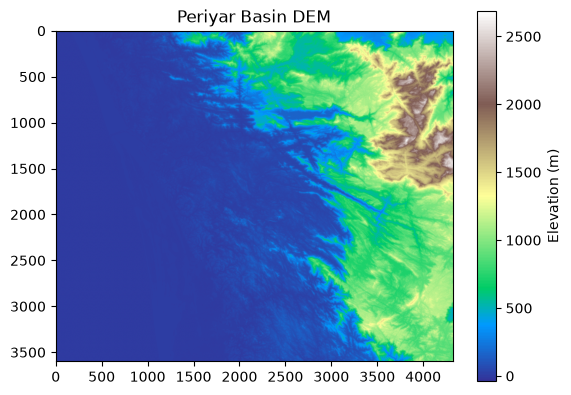

In [2]:
import rasterio
import matplotlib.pyplot as plt

with rasterio.open("../data/raw/periyar_dem.tif") as src:
    dem = src.read(1)
    print("Shape:", dem.shape)
    print("Elevation range:", dem.min(), "to", dem.max(), "meters")

plt.imshow(dem, cmap="terrain")
plt.colorbar(label="Elevation (m)")
plt.title("Periyar Basin DEM")
plt.show()

In [12]:
import numpy as np

# pysheds calls np.in1d, which NumPy 2.0 removed in favor of np.isin.
# Patch it back in so pysheds works regardless of installed NumPy version.
if not hasattr(np, "in1d"):
    np.in1d = np.isin

from pysheds.grid import Grid

grid = Grid.from_raster("../data/raw/periyar_dem.tif")
dem = grid.read_raster("../data/raw/periyar_dem.tif")

pit_filled = grid.fill_pits(dem)
flooded = grid.fill_depressions(pit_filled)
inflated = grid.resolve_flats(flooded)

fdir = grid.flowdir(inflated)
acc = grid.accumulation(fdir)

print("DEM shape:", dem.shape)
print("Flow accumulation range:", acc.min(), "to", acc.max())

DEM shape: (3600, 4320)
Flow accumulation range: 1.0 to 3605318.0


In [13]:
# define "river" cells as anywhere flow accumulation exceeds a threshold
# (cells with a lot of upstream drainage are channels, not just hillslope)
river_threshold = 1000
rivers = acc > river_threshold

print("Number of river cells:", rivers.sum())
print("Percent of basin that's river:", 100 * rivers.sum() / rivers.size, "%")

Number of river cells: 517319
Percent of basin that's river: 3.3263824588477364 %


HAND shape: (3600, 4320)
HAND range: 0.0 to 1172.0 meters


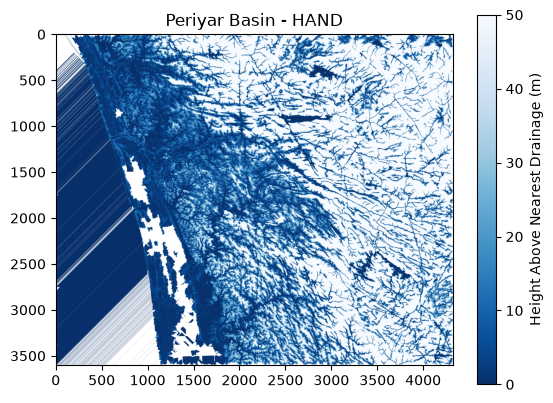

In [15]:
hand = grid.compute_hand(fdir, inflated, rivers)

print("HAND shape:", hand.shape)
print("HAND range:", np.nanmin(hand), "to", np.nanmax(hand), "meters")

import matplotlib.pyplot as plt
plt.imshow(hand, cmap="Blues_r", vmax=50)
plt.colorbar(label="Height Above Nearest Drainage (m)")
plt.title("Periyar Basin - HAND")
plt.show()

Susceptibility range: nan to nan


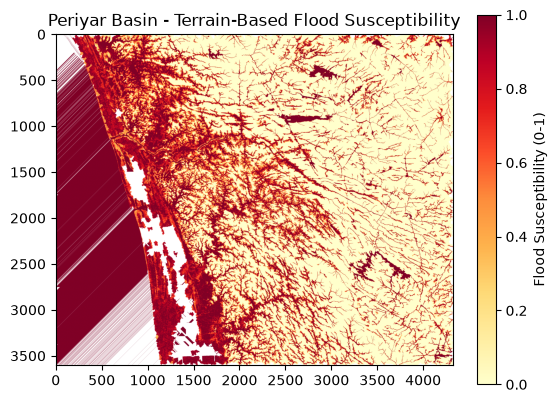

In [16]:
import numpy as np

# lower HAND = closer to drainage = higher flood susceptibility
# convert to a 0-1 susceptibility score (inverse, capped at 20m — beyond that, river flooding risk is negligible)
hand_capped = np.clip(hand, 0, 20)
susceptibility = 1 - (hand_capped / 20)

print("Susceptibility range:", susceptibility.min(), "to", susceptibility.max())

plt.imshow(susceptibility, cmap="YlOrRd")
plt.colorbar(label="Flood Susceptibility (0-1)")
plt.title("Periyar Basin - Terrain-Based Flood Susceptibility")
plt.show()

In [17]:
from pathlib import Path

Path("../data/processed").mkdir(exist_ok=True, parents=True)
np.save("../data/processed/periyar_susceptibility.npy", susceptibility)

# also save the DEM's geo-referencing info so we can map pixel coordinates back to lat/lon later
print("Grid bbox:", grid.bbox)
print("Grid shape:", susceptibility.shape)

import json
with open("../data/processed/periyar_grid_meta.json", "w") as f:
    json.dump({
        "bbox": list(grid.bbox),
        "shape": list(susceptibility.shape),
    }, f)
print("Saved susceptibility array and grid metadata")

Grid bbox: (75.99986111114504, 9.5001388888822, 77.1998611111452, 10.500138888882333)
Grid shape: (3600, 4320)
Saved susceptibility array and grid metadata
